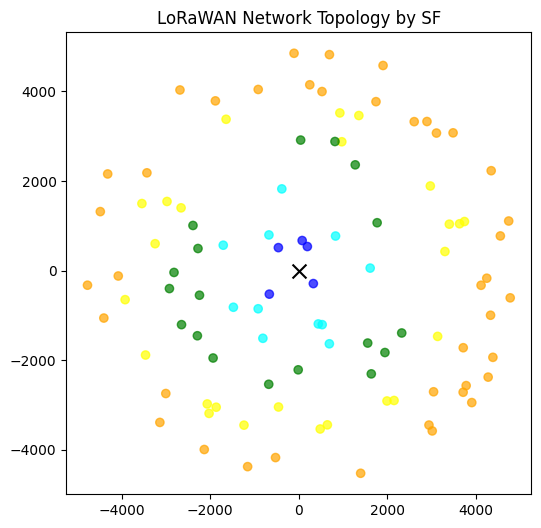

ToA for 20 bytes at SF10: 329.73 ms


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import math

N_NODES = 100 
R_MAX = 5000 

U = np.random.uniform(0, 1, N_NODES)
radii = R_MAX * np.sqrt(U) 
angles = np.random.uniform(0, 2*np.pi, N_NODES) 

x_coords = radii * np.cos(angles) 
y_coords = radii * np.sin(angles) 

sfs = []
colors = {7: 'blue', 8: 'cyan', 9: 'green', 10: 'yellow', 11: 'orange', 12: 'red'}
node_colors = []

for r in radii:
    if r <= 1000: sf = 7
    elif r <= 2000: sf = 8
    elif r <= 3000: sf = 9
    elif r <= 4000: sf = 10
    elif r <= 5000: sf = 11
    else: sf = 12
    sfs.append(sf)
    node_colors.append(colors[sf])

plt.figure(figsize=(6, 6))
plt.scatter(x_coords, y_coords, c=node_colors, alpha=0.7) 
plt.scatter(0, 0, c='black', marker='x', s=100, label='Gateway')
plt.title("LoRaWAN Network Topology by SF")
plt.show()

def calculate_toa(PL, SF, BW, CR, H=1, DE=0):
    Ts = (2**SF) / BW 
    T_preamble = (8 + 4.25) * Ts
    
    numerator = 8*PL - 4*SF + 28 + 16 - 20*H 
    denominator = 4*(SF - 2*DE)
    
    n_payload = 8 + max(math.ceil(numerator / denominator) * (CR + 4), 0) 
    toa_sec = T_preamble + (n_payload * Ts) 
    return toa_sec * 1000  

test_toa = calculate_toa(PL=20, SF=10, BW=125e3, CR=1) # CR=1 means 4/5 
print(f"ToA for 20 bytes at SF10: {test_toa:.2f} ms")

In [ ]:
import simpy
import random
from tqdm import tqdm

class LoRaGateway:
    def __init__(self, env):
        self.env = env
        self.channel_active_until = {sf: 0 for sf in range(7, 13)}
        self.successful_packets = 0
        self.total_packets = 0

def node_process(env, gateway, node_sf):
    toa = calculate_toa(PL=20, SF=node_sf, BW=125e3, CR=1)
    
    while True:
        yield env.timeout(random.expovariate(1.0 / 120000))
        
        gateway.total_packets += 1
        current_time = env.now
        
        if current_time >= gateway.channel_active_until[node_sf]:
            gateway.successful_packets += 1
            gateway.channel_active_until[node_sf] = current_time + toa
        else:
            gateway.channel_active_until[node_sf] = max(gateway.channel_active_until[node_sf], current_time + toa)

env = simpy.Environment()
gw = LoRaGateway(env)

for sf in sfs: 
    env.process(node_process(env, gw, sf))

for t in tqdm(range(0, 3600000, 60000), desc="Simulating 1 Hour"):
    env.run(until=t+60000)

pdr = (gw.successful_packets / gw.total_packets) * 100 if gw.total_packets > 0 else 0
print(f"\nTask 2.3 - Simulation Complete!")
print(f"Total Packets Sent: {gw.total_packets}")
print(f"Successful Packets: {gw.successful_packets}")
print(f"Final Packet Delivery Ratio (PDR): {pdr:.2f}%")


Simulating 1 Hour: 100%|██████████| 60/60 [00:00<00:00, 7966.14it/s]


Task 2.3 - Simulation Complete!
Total Packets Sent: 3139
Successful Packets: 2741
Final Packet Delivery Ratio (PDR): 87.32%
